In [1]:
import numpy as np
import pandas as pd
import pickle
import warnings
warnings.filterwarnings('ignore')

import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre

from pathlib import Path

# Reload module to ensure using the latest version (if utils_clean.py was modified)
import importlib
import utils_clean
importlib.reload(utils_clean)
from utils_clean import (
    prepare_training_data,
    evaluate_autosort_model,
    match_neurons,
    calibration_model,
    real_time_processing,
    generate_confusion_matrix_df,
    compute_noise_detection_metrics,
    visualize_umap_features,
    SimpleAutoSort,
    SimpleWaveformLoader
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load data
recording_path = '/media/ubuntu/sda/data/mouse6/ns4/natural_image/mouse6_031722_natural_image_001.ns4'
spike_inf_path = "/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/kilosort_spike_sorting/sorting_new/031722/spike_inf.tsv"
neuron_inf_path = "/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/kilosort_spike_sorting/sorting_new/031722/neuron_inf.pkl"

# Load training data neuron_inf (for getting valid_channels)
train_neuron_inf_path = "/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/kilosort_spike_sorting/sorting_new/021322/neuron_inf.pkl"
with open(train_neuron_inf_path, 'rb') as f:
    train_neuron_inf = pickle.load(f)

# Extract all unique tract_channels from training data neuron_inf as valid_channels
valid_channels = sorted(train_neuron_inf['tract_channel'].unique().tolist())
print(f"Number of valid channels extracted from training data neuron_inf: {len(valid_channels)}")
print(f"Valid channels list: {valid_channels}")

# Load evaluation data GT
spike_inf = pd.read_csv(spike_inf_path, sep='\t', index_col=0)
with open(neuron_inf_path, 'rb') as f:
    neuron_inf = pickle.load(f)

# Filter spike_inf: remove spikes from neurons not in valid_channels
# First, create mapping from neuron to tract_channel
neuron_to_tract_channel = dict(zip(neuron_inf['Neuron'], neuron_inf['tract_channel']))

# Filter spike_inf: keep only spikes from neurons with tract_channel in valid_channels
spike_inf_filtered = spike_inf[spike_inf['neuron'].isin(neuron_to_tract_channel.keys())].copy()
spike_inf_filtered = spike_inf_filtered[
    spike_inf_filtered['neuron'].map(neuron_to_tract_channel).isin(valid_channels)
]

original_spike_count = len(spike_inf)
filtered_spike_count = len(spike_inf_filtered)
removed_spike_count = original_spike_count - filtered_spike_count

print(f"\nFiltering spike_inf:")
print(f"  Original spike count: {original_spike_count}")
print(f"  Filtered spike count: {filtered_spike_count}")
print(f"  Removed spike count: {removed_spike_count} ({removed_spike_count/original_spike_count*100:.2f}%)")

# Also filter neuron_inf: keep only neurons with tract_channel in valid_channels
neuron_inf_filtered = neuron_inf[neuron_inf['tract_channel'].isin(valid_channels)].copy()
original_neuron_count = len(neuron_inf)
filtered_neuron_count = len(neuron_inf_filtered)
removed_neuron_count = original_neuron_count - filtered_neuron_count

print(f"\nFiltering neuron_inf:")
print(f"  Original neuron count: {original_neuron_count}")
print(f"  Filtered neuron count: {filtered_neuron_count}")
print(f"  Removed neuron count: {removed_neuron_count} ({removed_neuron_count/original_neuron_count*100:.2f}%)")

# Use filtered data
spike_inf = spike_inf_filtered
neuron_inf = neuron_inf_filtered

# Load and preprocess recording
recording_raw = se.read_blackrock(file_path=recording_path)
recording_recorded = recording_raw.remove_channels(["98", '31', '32'])
recording_f = spre.bandpass_filter(recording_recorded, freq_min=300, freq_max=3000)
recording_f = spre.common_reference(recording_f, reference="global", operator="median")

print(f"\nRecording loaded successfully")
print(f"Sampling rate: {recording_f.get_sampling_frequency()} Hz")
print(f"Number of channels: {recording_f.get_num_channels()}")


Number of valid channels extracted from training data neuron_inf: 23
Valid channels list: [0, 3, 4, 5, 6, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 26, 27]

Filtering spike_inf:
  Original spike count: 965913
  Filtered spike count: 862562
  Removed spike count: 103351 (10.70%)

Filtering neuron_inf:
  Original neuron count: 28
  Filtered neuron count: 23
  Removed neuron count: 5 (17.86%)

Recording loaded successfully
Sampling rate: 10000.0 Hz
Number of channels: 30


## Step 1: Prepare Evaluation Data

You can choose:
- **Option A**: Use existing training data (if training pipeline has been run)
- **Option B**: Re-prepare data (if evaluating new data)


In [61]:
# Set paths
save_dir = "/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/autosort_input/"
eval_data_dir = Path(save_dir) / "eval_data"  # Evaluation data directory

# Option A: Use existing data (if data already exists)
use_existing_data = False  # Set to False to re-prepare data

if use_existing_data and (eval_data_dir / "train_data").exists():
    eval_train_data_dir = eval_data_dir / "train_data"
    print(f"Using existing evaluation data: {eval_train_data_dir}")
    print("If data doesn't exist or needs to be re-prepared, set use_existing_data = False")
else:
    # Option B: Re-prepare data
    print("Re-preparing evaluation data...")
    duration_seconds = 200  # Processing duration (seconds)
    
    # Detection parameters (consistent with training)
    detection_params = {
        'thr_min': 3.5,
        'thr_max': 30,
        'distance': 3,
        'ch_max_simul_firing': 5,
        'wlen': 5,
        'prominence': 10,
    }
    
    # Waveform window parameters
    window_params = {
        'left_sample': 10,
        'right_sample': 20,
    }
    
    # Prepare data (save to eval_data directory)
    # Pass valid_channels to detect only on valid channels
    eval_train_data_dir = prepare_training_data(
        recording_f=recording_f,
        spike_inf=spike_inf,
        neuron_inf=neuron_inf,
        save_dir=str(eval_data_dir) + "/",  # Save to eval_data directory
        duration_seconds=duration_seconds,
        valid_channels=valid_channels,  # Pass valid_channels parameter to detect only on valid channels
        **detection_params,
        **window_params
    )

# Set data directory to use for evaluation
train_data_dir = eval_train_data_dir


Re-preparing evaluation data...
### 1. Threshold Detection
Sampling rate: 10000.0 Hz, Number of channels: 30
Recording total length: 26000100 samples (2600.01 seconds)
Will process first 2000000 samples (200.00 seconds)
Number of valid channels: 23
Valid channels list: [0, 3, 4, 5, 6, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 26, 27]
Data shape: (2000000, 30)
Building detect_array...
Number of detected spikes: 348606

### 2. Load Ground Truth and Match
Building gt_array...
GT spike count: 83288
---spike detection rate: 0.9507
Number of matched spikes: 79186
Number of unmatched spikes: 269420

### 3. Extract Waveforms


Extracting waveforms: 100%|██████████| 30/30 [00:07<00:00,  3.98it/s]


Waveform extraction completed!
waveform shape: (348599, 30, 30)

### 4. Save Training Data
Save directory: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/autosort_input/eval_data/train_data
  ✓ neuron_mapping.pkl saved
Saving data...
  ✓ X_waveform.pkl saved
  ✓ Y_spike_id.pkl saved
  ✓ Y_spike_id_noise.pkl saved
  ✓ X_spiketrain_time.pkl saved

All data saved to: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/autosort_input/eval_data/train_data
Data statistics:
  - Total spike count: 348599
  - Number of channels: 30
  - Window length: 30
  - Number of unique units: 23
  - Noise spike count: 269414
  - Valid spike count: 79185


## Step 2: Load Model and Evaluate


In [62]:
eval_neuron_inf_matched = match_neurons(
    train_neuron_inf=train_neuron_inf,
    eval_neuron_inf=neuron_inf,
    position_threshold=10,  # Position distance threshold (Euclidean distance, in microns)
    waveform_similarity_threshold=0.95  # Waveform similarity threshold (Pearson correlation coefficient)
)



Neuron Matching
Matching neurons...
  Neuron_6 -> Neuron_1 (Similarity: 0.9864, Position distance: 7.60)
  Neuron_16 -> Neuron_22 (Similarity: 0.9958, Position distance: 2.83)
  Neuron_17 -> Neuron_20 (Similarity: 0.9567, Position distance: 5.57)
  Neuron_19 -> Neuron_17 (Similarity: 0.9922, Position distance: 5.97)
  Neuron_22 -> Neuron_28 (Similarity: 0.9887, Position distance: 3.27)
  Neuron_26 -> Neuron_34 (Similarity: 0.9959, Position distance: 8.80)
  Neuron_28 -> Neuron_31 (Similarity: 0.9970, Position distance: 4.19)
  Neuron_32 -> Neuron_30 (Similarity: 0.9975, Position distance: 8.38)
  Neuron_36 -> Neuron_42 (Similarity: 0.9977, Position distance: 3.43)
  Neuron_37 -> Neuron_45 (Similarity: 0.9912, Position distance: 7.11)
  Neuron_43 -> Neuron_45 (Similarity: 0.9548, Position distance: 6.14)
  Neuron_45 -> Neuron_51 (Similarity: 0.9918, Position distance: 3.49)
  Neuron_47 -> Neuron_53 (Similarity: 0.9712, Position distance: 3.41)
  Neuron_52 -> Neuron_57 (Similarity: 0.986

## Step 3: Load Model and Evaluate


In [63]:
# Set evaluation parameters
model_save_dir = save_dir + "model_save/"
n_channels = recording_f.get_num_channels()

evaluation_params = {
    'batch_size': 512,
    'left_sample': 10,
    'right_sample': 20,
}

# Evaluate model (pass matched neuron_inf, compute two sets of results)
results = evaluate_autosort_model(
    train_data_dir=train_data_dir,  # Evaluation data directory
    model_save_dir=model_save_dir,
    n_channels=n_channels,
    **evaluation_params,
    save_results=True,
    eval_neuron_inf_matched=eval_neuron_inf_matched,  # Pass matched neuron_inf
    eval_data_dir=train_data_dir  # Evaluation data directory (for loading neuron_mapping)
)

print("\nEvaluation completed!")


Using device: cuda
Loading unit ID list from training file: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/autosort_input/model_save/keep_id.pkl
Number of units during training: 27
Create dataset...
Dataset loaded:
  - Total samples: 348599
  - Number of channels: 30
  - Window length: 30
  - Number of unique units: 27
  - Noise samples: 269414.0
  - Non-noise samples: 79185.0
Model parameters:
  - Number of channels: 30
  - Window length: 30
  - Number of units: 27
  - Using training unit ID list: True
Loading model weights...
Model loaded successfully

Starting evaluation (total 348599 samples)...


Evaluating: 100%|██████████| 681/681 [00:03<00:00, 207.45it/s]



Evaluation results (original):
  - Noise classification accuracy: 0.8512
  - Unit classification accuracy: 0.0153
  - Unit classification F1 score: 0.0153
  - Number of unit samples evaluated: 79185
  - Total samples: 348599

Computing adjusted evaluation results (treating unmatch neuron as noise)...
  - Number of unmatched neurons: 6
  - Unmatched neurons: ['Neuron_4' 'Neuron_10' 'Neuron_11' 'Neuron_21' 'Neuron_42' 'Neuron_49']
  - Number of adjusted samples: 9267

Evaluation results (adjusted):
  - Noise classification accuracy: 0.8499
  - Total samples: 348599
  - Unit classification accuracy: 0.0611
  - Unit classification F1 score: 0.0062
  - Number of unit samples evaluated: 79185
    - Matched neuron samples: 69918
    - Unmatched neuron samples: 9267
      - Correctly identified as noise: 4411 (47.6%)
      - Misclassified as unit: 4856 (52.4%)
    - Note: unmatched neuron samples are treated as noise, correctly identified as noise counts as correct, misclassified as unit coun

## Step 4: Optimized Classification Pipeline (Two-Stage Method)

Using a new two-stage method:
- **Stage 1 (Calibration)**: First 60s of data, extract way3 features, PCA dimensionality reduction, K-means clustering, match with train neurons
- **Stage 2 (Real-time Processing)**: Process by time_window, use models and mapping relationships established in Stage 1


In [64]:
# Load model
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create model (need to load dataset first to get keep_id and weights)
model_save_dir = save_dir + "model_save/"
n_channels = recording_f.get_num_channels()

# Load keep_id
with open(model_save_dir + 'keep_id.pkl', 'rb') as f:
    keep_id = pickle.load(f)

# Create dataset to get weights (for model initialization, but won't be used during evaluation)
dataset = SimpleWaveformLoader(
    root=str(train_data_dir) + '/',
    shank_channel=np.arange(n_channels),
    Keep_id=keep_id
)

# Create model
autosort_model = SimpleAutoSort(
    ch_num=n_channels,
    samplepoints=30,  # left_sample + right_sample
    device=device,
    set_shank_id=keep_id,
    save_dir=model_save_dir,
    pos_weight_noise=dataset.pos_weight_noise.to(device),
    pos_weight_label=dataset.pos_weight_label.to(device)
)

# Load model weights
autosort_model.load_model()
autosort_model.eval()
print("Model loaded successfully")


Using device: cuda
Dataset loaded:
  - Total samples: 348599
  - Number of channels: 30
  - Window length: 30
  - Number of unique units: 27
  - Noise samples: 269414.0
  - Non-noise samples: 79185.0
Model loaded successfully


In [69]:
# Stage 1: Calibration (first 60 seconds)
calibration_duration_seconds = 60
n_additional_clusters = 10  # Number of additional clusters

detection_params = {
    'thr_min': 3.5,
    'thr_max': 30,
    'distance': 3,
    'ch_max_simul_firing': 5,
    'wlen': 5,
    'prominence': 10,
}

window_params = {
    'left_sample': 10,
    'right_sample': 20,
}

calibration_results = calibration_model(
    recording_f=recording_f,
    autosort_model=autosort_model,
    train_neuron_inf=train_neuron_inf,
    calibration_duration_seconds=calibration_duration_seconds,
    n_additional_clusters=n_additional_clusters,
    detection_params=detection_params,
    window_params=window_params,
    position_threshold=10.0,
    waveform_similarity_threshold=0.9,
    eval_neuron_inf=eval_neuron_inf_matched,  # Use matched neuron_inf
    eval_spike_inf=spike_inf,  # Use spike_inf
    device=device,
)


Stage 1: Calibration (first 60 seconds)
Loading first 60 seconds of data...
Data shape: (30, 600000)

### 2. Threshold detection
Number of detected spikes: 133412

### 3. Extract waveforms
Number of valid spikes: 133407

### 4. Noise classifier filtering


Noise classification: 100%|██████████| 261/261 [00:00<00:00, 766.09it/s]


Number of spikes passing noise classifier: 37503

### 5. PCA dimensionality reduction
Feature shape after PCA dimensionality reduction: (37503, 30)
PCA explained variance ratio: 0.9184

### 6. K-means clustering
Number of clusters: 37 (Training neurons: 27, additional: 10)
Clustering completed, number of samples per cluster:
  Cluster 0: 298 samples
  Cluster 1: 1126 samples
  Cluster 2: 1603 samples
  Cluster 3: 1762 samples
  Cluster 4: 656 samples
  Cluster 5: 654 samples
  Cluster 6: 1210 samples
  Cluster 7: 1187 samples
  Cluster 8: 1139 samples
  Cluster 9: 908 samples
  Cluster 10: 1002 samples
  Cluster 11: 2847 samples
  Cluster 12: 2763 samples
  Cluster 13: 816 samples
  Cluster 14: 1171 samples
  Cluster 15: 404 samples
  Cluster 16: 892 samples
  Cluster 17: 1293 samples
  Cluster 18: 506 samples
  Cluster 19: 703 samples
  Cluster 20: 598 samples
  Cluster 21: 529 samples
  Cluster 22: 933 samples
  Cluster 23: 1059 samples
  Cluster 24: 1242 samples
  Cluster 25: 489 sa

Extracting way3 features for all spikes: 100%|██████████| 261/261 [01:56<00:00,  2.23it/s]


### 8. Calculate 6-channel waveforms for matched neurons
  Neuron Neuron_1: 6 channels, 682 spikes
  Neuron Neuron_2: 6 channels, 261 spikes
  Neuron Neuron_17: 6 channels, 294 spikes
  Neuron Neuron_20: 6 channels, 330 spikes
  Neuron Neuron_22: 6 channels, 768 spikes
  Neuron Neuron_25: 6 channels, 87 spikes
  Neuron Neuron_27: 6 channels, 307 spikes
  Neuron Neuron_30: 6 channels, 1064 spikes
  Neuron Neuron_31: 6 channels, 2674 spikes
  Neuron Neuron_34: 6 channels, 1567 spikes
  Neuron Neuron_40: 6 channels, 490 spikes
  Neuron Neuron_42: 6 channels, 736 spikes
  Neuron Neuron_43: 6 channels, 309 spikes
  Neuron Neuron_45: 6 channels, 785 spikes
  Neuron Neuron_51: 6 channels, 523 spikes
  Neuron Neuron_52: 6 channels, 575 spikes
  Neuron Neuron_53: 6 channels, 808 spikes
  Neuron Neuron_55: 6 channels, 1248 spikes
  Neuron Neuron_57: 6 channels, 971 spikes
  Neuron Neuron_69: 6 channels, 799 spikes
  Neuron Neuron_70: 6 channels, 1234 spikes
Calculated 6-channel waveforms for 21

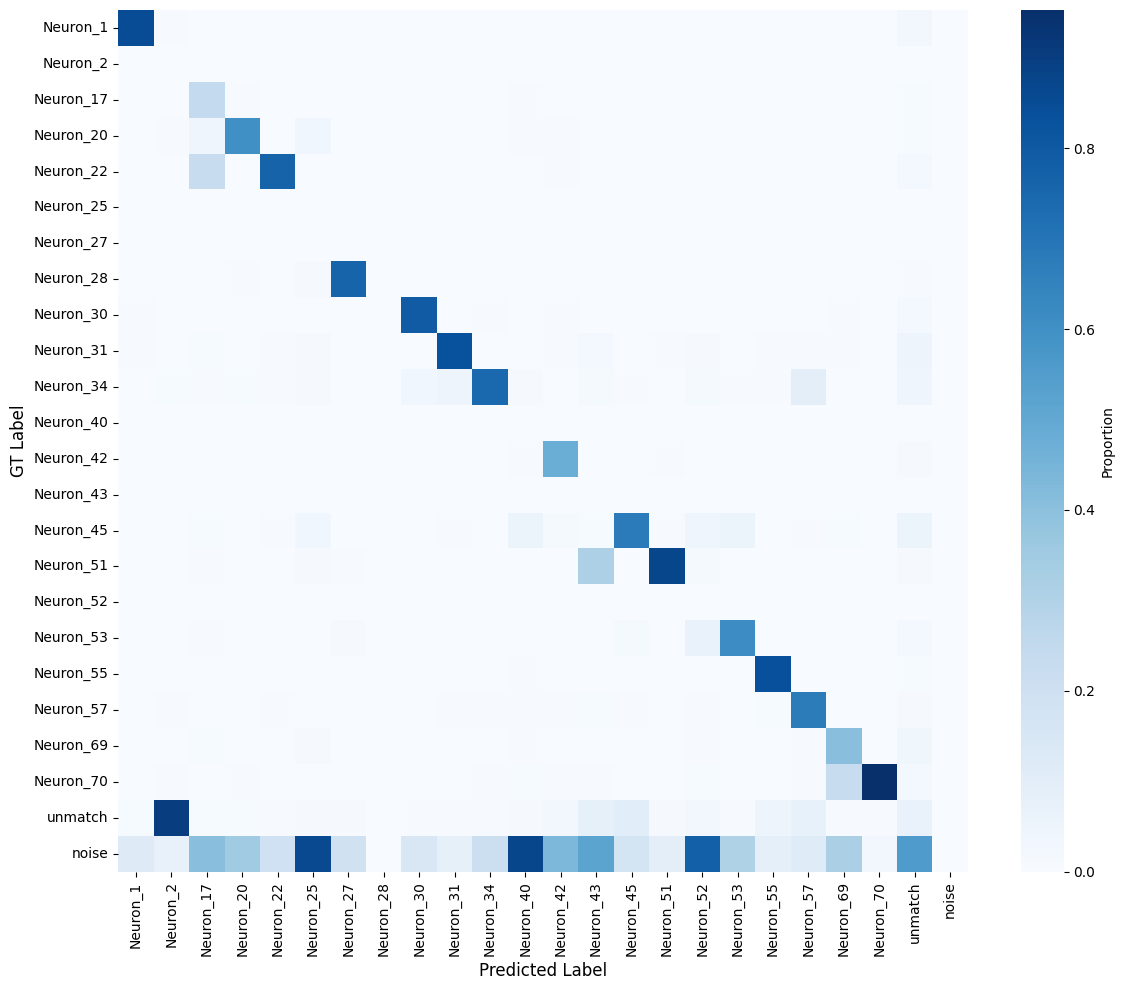

In [18]:
# Calibration stage Confusion Matrix validation
if calibration_results['results_df'] is not None and 'gt_label' in calibration_results['results_df'].columns:
    calib_results_df = calibration_results['results_df']
    
    # Get train neuron list (for sorting)
    train_neuron_list = train_neuron_inf['Neuron'].tolist()
    
    # Generate confusion matrix
    calib_confusion_matrix, calib_summary_df = generate_confusion_matrix_df(
        results_df=calib_results_df,
        train_neuron_list=train_neuron_list
    )
    
    
    # Plot Confusion Matrix heatmap (raw counts)
    calib_confusion_matrix_plot = calib_confusion_matrix.copy()
    if 'All' in calib_confusion_matrix_plot.index:
        calib_confusion_matrix_plot = calib_confusion_matrix_plot.drop('All')
    if 'All' in calib_confusion_matrix_plot.columns:
        calib_confusion_matrix_plot = calib_confusion_matrix_plot.drop('All', axis=1)
    
    calib_confusion_matrix_normalized = calib_confusion_matrix_plot.copy()
    # Normalize by column (each column sums to 1)
    column_sums = calib_confusion_matrix_normalized.sum(axis=0)
    # Avoid division by zero
    column_sums = column_sums.replace(0, 1)
    calib_confusion_matrix_normalized = calib_confusion_matrix_normalized.div(column_sums, axis=1)
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        calib_confusion_matrix_normalized, 
        annot=False, 
        cmap='Blues',
        cbar_kws={'label': 'Proportion'}
    )
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('GT Label', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    if 'gt_label' in calib_summary_df.columns and 'predicted_label' in calib_summary_df.columns:
        # Only calculate matched neurons (exclude unmatch and noise)
        matched_df = calib_summary_df[
            (calib_summary_df['gt_label'] != 'unmatch') & 
            (calib_summary_df['gt_label'] != 'noise') &
            (calib_summary_df['predicted_label'] != 'unmatch')
        ]
        
        if len(matched_df) > 0:
            accuracy = (matched_df['gt_label'] == matched_df['predicted_label']).sum() / len(matched_df)
        
        noise_df = calib_summary_df[calib_summary_df['gt_label'] == 'noise']

else:
    print("Warning: Calibration stage has no GT label data, cannot generate Confusion Matrix")


In [ ]:
prop = (noise_df['predicted_label'] == 'unmatch').sum()/len(calib_results_df)
N = len(results['gt_noise'])

acc_old = (results['noise_predictions'] == results['gt_noise']).mean()
FP = ((results['noise_predictions'] == 1) & (results['gt_noise'] == 0)).sum()

acc_new = acc_old + prop * FP / N

print(f"Accuracy before adjustment: {acc_old:.6f}")
print(f"FP count: {FP}")
print(f"Accuracy after adjustment: {acc_new:.6f}")

矫正前准确率: 0.840758
FP 数量: 54088
矫正后准确率: 0.851382


## Step 5.5: Visualize Calibration Neuron Waveforms (6 Channels)


In [74]:
from utils_clean import CHANNEL_POSITION

def plot_neuron_6channel_waveform(
    neuron_name,
    cluster_id,
    waveforms_6ch,
    channel_ids,
    channel_positions,
    window_size=30,
    sampling_rate=10000.0,
    save_path=None,
):
    """
    Plot 6-channel waveform for a neuron, arranged in 2x3 subplot based on channel positions.
    
    Parameters:
        neuron_name: name of the neuron
        cluster_id: cluster ID matched to this neuron
        waveforms_6ch: numpy array, shape (6, window_size) - average waveforms for 6 channels
        channel_ids: list of 6 channel IDs (probe channel indices)
        channel_positions: list of (x, y) tuples for 6 channels
        window_size: window size in samples
        sampling_rate: sampling rate in Hz
        save_path: path to save the figure
    """
    # Sort channels by position (y first, then x) to arrange in 2x3 grid
    # Top row: higher y values, Bottom row: lower y values
    # Left to right: lower x values to higher x values
    channel_data = list(zip(channel_ids, waveforms_6ch, channel_positions))
    channel_data.sort(key=lambda x: (-x[2][1], x[2][0]))  # Sort by -y (descending), then x (ascending)
    
    # Create 2x3 subplot
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(f'Neuron {neuron_name} - Cluster {cluster_id} - 6-Channel Waveforms', 
                 fontsize=16, fontweight='bold')
    
    # Time axis in milliseconds
    time_ms = np.arange(window_size) / sampling_rate * 1000
    
    # Calculate global min and max across all 6 channels for unified y-axis range
    all_waveform_values = np.concatenate([wf for _, wf, _ in channel_data])
    y_min = np.min(all_waveform_values)
    y_max = np.max(all_waveform_values)
    
    # Add small margin (5% of range) for better visualization
    y_range = y_max - y_min
    if y_range > 0:
        y_margin = y_range * 0.05
        y_min_unified = y_min - y_margin
        y_max_unified = y_max + y_margin
    else:
        # If all values are the same, set a small range around the value
        y_min_unified = y_min - 1
        y_max_unified = y_max + 1
    
    for idx, (ch_id, waveform, (x_pos, y_pos)) in enumerate(channel_data):
        row = idx // 3
        col = idx % 3
        ax = axes[row, col]
        
        ax.plot(time_ms, waveform, linewidth=15, color='#2E86AB')
        ax.set_xlabel('Time (ms)', fontsize=10)
        ax.set_ylabel('Amplitude (μV)', fontsize=10)
        ax.set_title(f'Channel {ch_id}\nPosition: ({x_pos:.1f}, {y_pos:.1f})', 
                     fontsize=11, fontweight='bold')
        ax.grid(False)
        # Set unified y-axis range for all subplots
        ax.set_ylim(y_min_unified, y_max_unified)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"  Saved waveform plot to {save_path}")
    
    return fig


# Visualize calibration neuron waveforms using data from calibration_results
print("=" * 80)
print("Visualizing Calibration Neuron Waveforms (6 Channels)")
print("=" * 80)

# Check if calibration_results exists
if 'calibration_results' not in locals() or calibration_results is None:
    print("Warning: calibration_results not found. Please run calibration stage first.")
else:
    neuron_waveforms_6ch = calibration_results.get('neuron_waveforms_6ch', {})
    
    if len(neuron_waveforms_6ch) == 0:
        print("Warning: neuron_waveforms_6ch not found in calibration_results.")
        print("Please ensure calibration_model has been updated to include neuron_waveforms_6ch.")
    else:
        print(f"Found 6-channel waveforms for {len(neuron_waveforms_6ch)} neurons")
        
        # Create output directory
        output_dir = Path(save_dir) / "calibration_waveforms"
        output_dir.mkdir(parents=True, exist_ok=True)
        
        # Get window size and sampling rate
        window_size = window_params['left_sample'] + window_params['right_sample']
        sampling_rate = recording_f.get_sampling_frequency()
        
        # Plot waveforms for each neuron
        for neuron_name in sorted(neuron_waveforms_6ch.keys()):
            neuron_data = neuron_waveforms_6ch[neuron_name]
            
            waveforms_6ch = neuron_data['waveforms']  # (6, window_size)
            channel_ids = neuron_data['channel_ids']  # List of 6 channel IDs
            channel_positions = neuron_data['channel_positions']  # List of (x, y) tuples
            cluster_id = neuron_data.get('cluster_id', -1)
            
            print(f"\n{'-'*60}")
            print(f"Processing Neuron: {neuron_name} (Cluster {cluster_id})")
            print(f"{'-'*60}")
            print(f"  Number of spikes: {neuron_data.get('n_spikes', 'unknown')}")
            print(f"  Channel IDs: {channel_ids}")
            
            # Plot waveforms
            save_path = output_dir / f"neuron_{neuron_name}_cluster_{cluster_id}_waveforms.pdf"
            fig = plot_neuron_6channel_waveform(
                neuron_name=neuron_name,
                cluster_id=cluster_id,
                waveforms_6ch=waveforms_6ch,
                channel_ids=channel_ids,
                channel_positions=channel_positions,
                window_size=window_size,
                sampling_rate=sampling_rate,
                save_path=save_path,
            )
            plt.close(fig)
        
        print(f"\n{'='*80}")
        print(f"Waveform visualization completed!")
        print(f"Results saved to: {output_dir}")
        print(f"{'='*80}")


Visualizing Calibration Neuron Waveforms (6 Channels)
Found 6-channel waveforms for 21 neurons

------------------------------------------------------------
Processing Neuron: Neuron_1 (Cluster 13)
------------------------------------------------------------
  Number of spikes: 682
  Channel IDs: [1, 3, 7, 9, 11, 0]
  Saved waveform plot to /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/autosort_input/calibration_waveforms/neuron_Neuron_1_cluster_13_waveforms.pdf

------------------------------------------------------------
Processing Neuron: Neuron_17 (Cluster 18)
------------------------------------------------------------
  Number of spikes: 294
  Channel IDs: [13, 15, 19, 21, 23, 0]
  Saved waveform plot to /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/autosort_input/calibration_waveforms/neuron_Neuron_17_cluster_18_waveforms.pdf

----------------------------------------------------------

In [80]:
neuron_inf_color = ["#a74a5b", "#d64158", "#e28572", "#d6522c",
                    "#a5572c", "#da9131", "#d6a46a", "#8c6d2c",
                    "#c0ab39", "#6d7821", "#9cb835", "#67733a",
                    "#9eb56c", "#4c902f", "#61c350", "#418348",
                    "#54c083", "#338b70", "#51c6c0", "#609dd8",
                    "#6365ab", "#636edd", "#a85aca", "#c590d9",
                    "#9c4d88", "#d5449a", "#e280a9"]


Calibration阶段 UMAP可视化
1. Noise Detection UMAP可视化
  进行UMAP降维（50000个样本）...

2. Label Classification UMAP可视化
  过滤后有效点数: 46497 / 73689
  进行UMAP降维（46497个样本）...


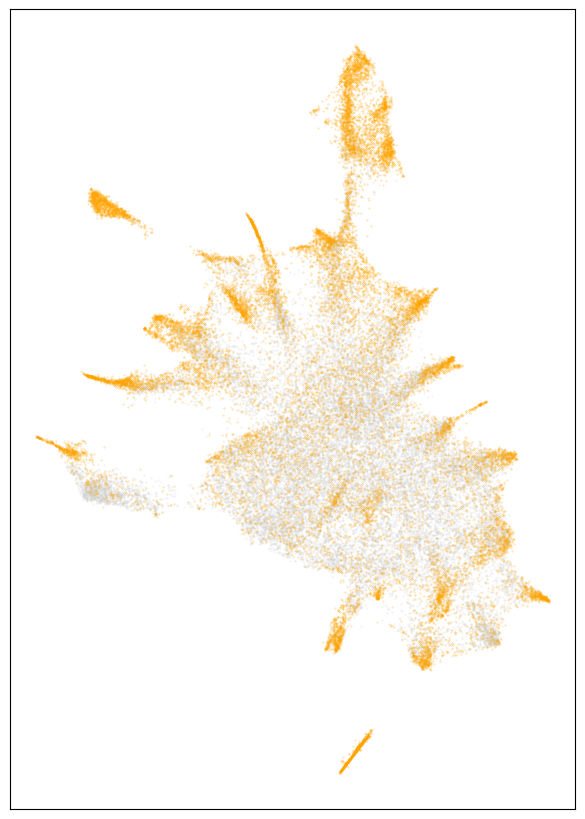

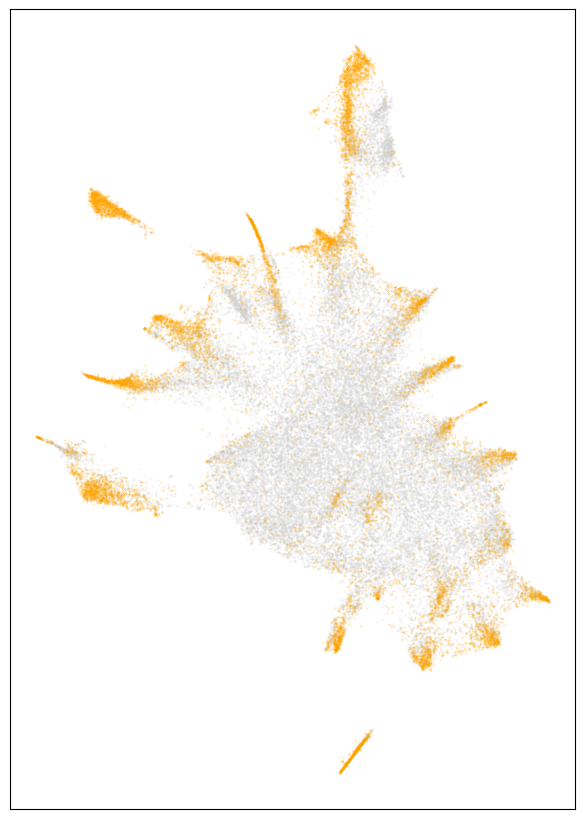

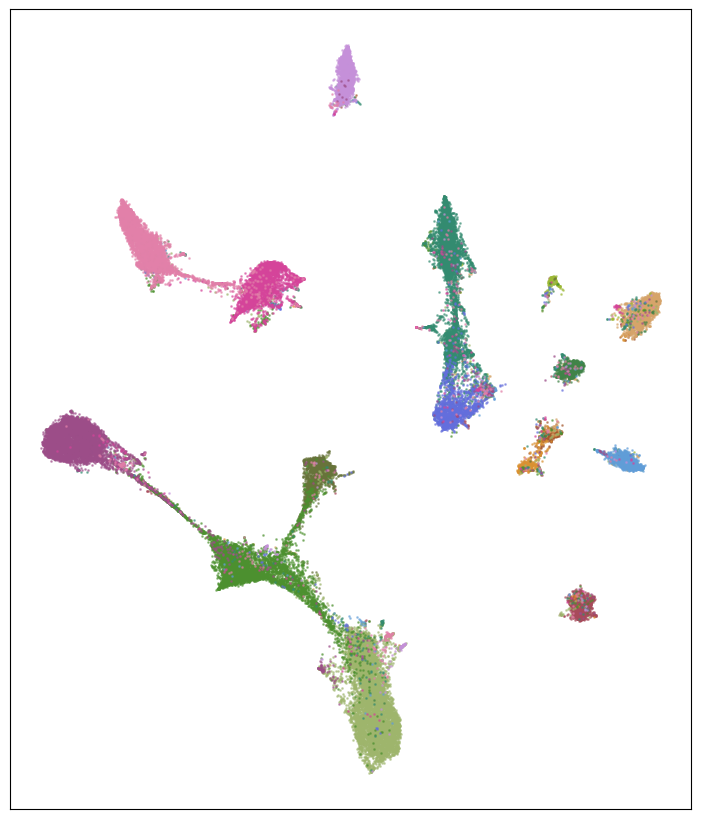

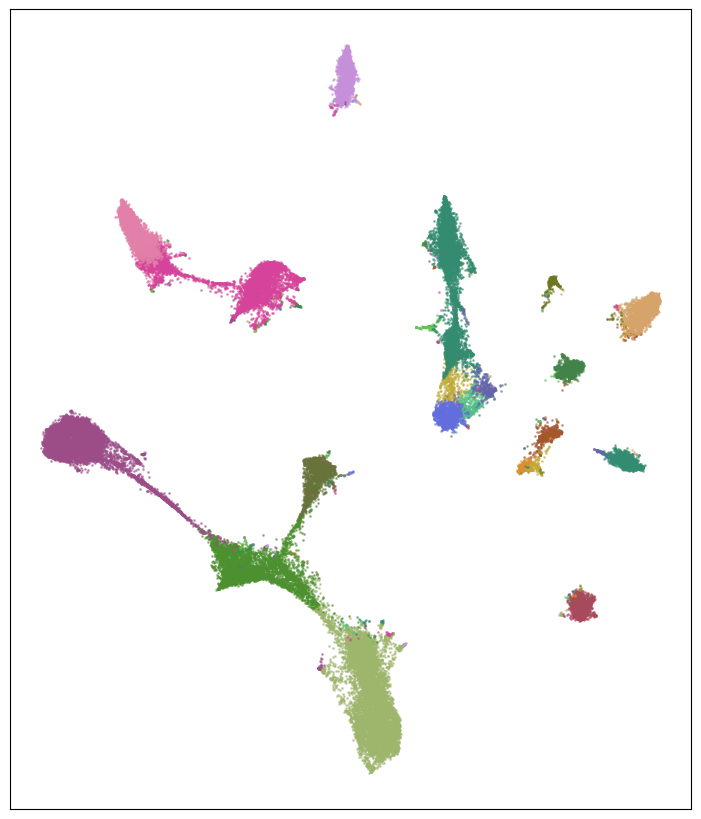

In [ ]:
# UMAP visualization
# 1. Calibration stage visualization
print("=" * 50)
print("Calibration Stage UMAP Visualization")
print("=" * 50)

# Prepare data
calib_way3_100d = calibration_results.get('way3_features_noise_100d', np.array([]))
calib_way3_30d = calibration_results.get('way3_features_30d', np.array([]))
calib_noise_gt_labels = calibration_results.get('noise_gt_labels', None)
calib_noise_pred_labels = calibration_results.get('noise_pred_labels', None)
calib_results_df = calibration_results.get('results_df', None)

# Create neuron color mapping dictionary
train_neuron_list = train_neuron_inf['Neuron'].tolist()
neuron_color_dict = {}
for i, neuron in enumerate(train_neuron_list):
    if i < len(neuron_inf_color):
        neuron_color_dict[neuron] = neuron_inf_color[i]
    else:
        # If neuron count exceeds color list, use default colors
        import matplotlib.pyplot as plt
        cmap = plt.cm.get_cmap('tab20')
        neuron_color_dict[neuron] = cmap(i % 20)

# Visualize
if len(calib_way3_100d) > 0 and len(calib_way3_30d) > 0 and calib_results_df is not None:
    fig = visualize_umap_features(
        way3_features_100d=calib_way3_100d,
        way3_features_30d=calib_way3_30d,
        results_df=calib_results_df,
        train_neuron_list=train_neuron_list,
        noise_gt_labels=calib_noise_gt_labels,
        noise_pred_labels=calib_noise_pred_labels,
        neuron_inf_color=neuron_color_dict,
        n_samples=50000,
        random_state=42
    )
    plt.show()
else:
    print("Warning: Calibration stage missing necessary feature data, cannot visualize")


## Step 6.5: Count GT and Predicted Neurons from Confusion Matrices


In [73]:
# Read confusion matrices from all dates and count GT and Predicted neurons
eval_results_dir = Path("/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/autosort_input/eval_results")

# Find all date directories
date_dirs = sorted([d for d in eval_results_dir.iterdir() if d.is_dir()])

# Collect data from all dates
neuron_count_data = []

for date_dir in date_dirs:
    date = date_dir.name
    confusion_matrix_path = date_dir / f"confusion_matrix_{date}.csv"
    
    if confusion_matrix_path.exists():
        # Read confusion matrix
        df = pd.read_csv(confusion_matrix_path, index_col=0)
        
        # Exclude 'unmatch', 'noise', and 'All' from neuron counts
        exclude_labels = ['unmatch', 'noise', 'All']
        
        # Count GT neurons: rows (excluding 'unmatch', 'noise', 'All') with non-zero total (last column 'All')
        gt_labels = [idx for idx in df.index if idx not in exclude_labels]
        gt_totals = df.loc[gt_labels, 'All']  # Get row totals (last column)
        n_gt_neurons = (gt_totals > 0).sum()  # Count rows with non-zero totals
        
        # Count Predicted neurons: columns (excluding 'unmatch', 'noise', 'All') with non-zero total (last row 'All')
        predicted_labels = [col for col in df.columns if col not in exclude_labels]
        predicted_totals = df.loc['All', predicted_labels]  # Get column totals (last row)
        n_predicted_neurons = (predicted_totals > 0).sum()  # Count columns with non-zero totals
        
        neuron_count_data.append({
            'date': date,
            'n_gt_neurons': n_gt_neurons,
            'n_predicted_neurons': n_predicted_neurons,
        })
        
        print(f"Date {date}: GT neurons = {n_gt_neurons}, Predicted neurons = {n_predicted_neurons}")
    else:
        print(f"Warning: {confusion_matrix_path} does not exist, skipping date {date}")

# Convert to DataFrame with shape (2, n_date)
if len(neuron_count_data) > 0:
    count_df = pd.DataFrame(neuron_count_data)
    count_df = count_df.sort_values('date')  # Sort by date
    
    # Create result DataFrame with shape (2, n_date)
    # First row: GT neuron counts
    # Second row: Predicted neuron counts
    # Columns: dates
    result_df = pd.DataFrame({
        date: [count_df[count_df['date'] == date]['n_gt_neurons'].values[0],
               count_df[count_df['date'] == date]['n_predicted_neurons'].values[0]]
        for date in count_df['date']
    }, index=['n_gt_neurons', 'n_predicted_neurons'])
    
    print(f"\n{'='*80}")
    print(f"Neuron Count Summary (Shape: {result_df.shape})")
    print(f"{'='*80}")
    print(result_df)
    
    # Save results
    output_path = Path(save_dir) / "neuron_count_summary.csv"
    result_df.to_csv(output_path)
    print(f"\nNeuron count summary saved to: {output_path}")
    
    # Also save the detailed data
    detailed_path = Path(save_dir) / "neuron_count_detailed.csv"
    count_df.to_csv(detailed_path, index=False)
    print(f"Detailed neuron count data saved to: {detailed_path}")
    
else:
    print("Warning: No confusion matrix files found")
    result_df = pd.DataFrame()


Date 022522: GT neurons = 15, Predicted neurons = 19
Date 031722: GT neurons = 16, Predicted neurons = 19
Date 042422: GT neurons = 20, Predicted neurons = 21
Date 052422: GT neurons = 17, Predicted neurons = 21
Date 062422: GT neurons = 18, Predicted neurons = 19
Date 072322: GT neurons = 18, Predicted neurons = 17
Date 082322: GT neurons = 18, Predicted neurons = 19
Date 092422: GT neurons = 19, Predicted neurons = 19
Date 102122: GT neurons = 18, Predicted neurons = 20
Date 112022: GT neurons = 18, Predicted neurons = 20
Date 122022: GT neurons = 18, Predicted neurons = 19

Neuron Count Summary (Shape: (2, 11))
                     022522  031722  042422  052422  062422  072322  082322  \
n_gt_neurons             15      16      20      17      18      18      18   
n_predicted_neurons      19      19      21      21      19      17      19   

                     092422  102122  112022  122022  
n_gt_neurons             19      18      18      18  
n_predicted_neurons      19     

## Step 5: Auto-correlation Analysis for Matched Neurons


In [26]:
# Calculate auto-correlation for each matched neuron
# Auto-correlation: ISI (Inter-Spike Interval) histogram

from scipy import signal
from scipy.stats import binned_statistic

# Get calibration results
calib_results_df = calibration_results['results_df']
calib_spike_times = calib_results_df['spike_time'].values
calib_spike_channels = calib_results_df['spike_channel'].values

if calib_results_df is None or len(calib_spike_times) == 0:
    print("Warning: No calibration results available for auto-correlation analysis")
else:
    # Get matched neurons (from predicted_label, excluding 'unmatch' and 'noise')
    matched_neurons = calib_results_df[
        (calib_results_df['predicted_label'] != 'unmatch') & 
        (calib_results_df['predicted_label'] != 'noise')
    ]['predicted_label'].unique()
    
    print(f"\n{'='*80}")
    print(f"Auto-correlation Analysis for {len(matched_neurons)} Matched Neurons")
    print(f"{'='*80}")
    
    # Load calibration data for waveform extraction
    sampling_rate = recording_f.get_sampling_frequency()
    calibration_duration_samples = int(calibration_duration_seconds * sampling_rate)
    calib_data = recording_f.get_traces(start_frame=0, end_frame=calibration_duration_samples)
    
    # Window parameters
    left_sample = window_params['left_sample']
    right_sample = window_params['right_sample']
    window_size = left_sample + right_sample
    
    # Create output directory
    output_dir = Path(save_dir) / "calibration_autocorr"
    output_dir.mkdir(parents=True, exist_ok=True)
    
    for neuron_name in sorted(matched_neurons):
        print(f"\n{'-'*60}")
        print(f"Processing Neuron: {neuron_name}")
        print(f"{'-'*60}")
        
        # Get spike times for this neuron
        neuron_spikes = calib_results_df[calib_results_df['predicted_label'] == neuron_name]
        neuron_spike_times = neuron_spikes['spike_time'].values
        neuron_spike_channels = neuron_spikes['spike_channel'].values
        
        if len(neuron_spike_times) < 2:
            print(f"  Skipping {neuron_name}: Only {len(neuron_spike_times)} spike(s), need at least 2 for auto-correlation")
            continue
        
        print(f"  Number of spikes: {len(neuron_spike_times)}")
        
        
        
        # 2. Calculate auto-correlation (all spike pairs)
        # Convert spike times to milliseconds
        spike_times_ms = neuron_spike_times / sampling_rate * 1000  # Convert to ms
        spike_times_ms_sorted = np.sort(spike_times_ms)
        
        # Calculate all pairwise time differences (auto-correlation)
        # For each spike pair (i, j), calculate time_diff = spike_times[j] - spike_times[i]
        # This gives both positive (j > i) and negative (j < i) delays
        n_spikes = len(spike_times_ms_sorted)
        time_diffs_positive = []
        time_diffs_negative = []
        
        for i in range(n_spikes):
            for j in range(i + 1, n_spikes):
                time_diff = spike_times_ms_sorted[j] - spike_times_ms_sorted[i]
                if 0 < time_diff <= 200:  # Positive delay, 0-200 ms
                    time_diffs_positive.append(time_diff)
                # For negative delay, we use symmetry: C(-tau) = C(tau)
                # So we also count the same difference for negative side
                if 0 < time_diff <= 200:
                    time_diffs_negative.append(time_diff)  # Same value for symmetry
        
        time_diffs_positive = np.array(time_diffs_positive)
        time_diffs_negative = np.array(time_diffs_negative)
        
        print(f"  Positive time differences count: {len(time_diffs_positive)}")
        print(f"  Negative time differences count: {len(time_diffs_negative)}")
        
        # 3. Create plots
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Plot 1: Waveform
        ax1 = axes[0]
        
        
        # Plot 2: Auto-correlation histogram
        ax2 = axes[1]
        
        # Create bins for histogram (0 to 200 ms, 1 ms bins)
        bins_positive = np.arange(0, 201, 2)
        
        # Calculate histogram for positive time differences
        hist_positive, bin_edges = np.histogram(time_diffs_positive, bins=bins_positive)
        
        # Calculate histogram for negative time differences (same bins, using symmetry)
        hist_negative, _ = np.histogram(time_diffs_negative, bins=bins_positive)
        
        # Plot positive time differences (right side, 0 to 200 ms)
        bin_centers_positive = (bin_edges[:-1] + bin_edges[1:]) / 2
        ax2.bar(bin_centers_positive, hist_positive, width=2, color='gray', alpha=1)
        
        # Plot negative time differences (left side, -200 to 0 ms, mirrored)
        bin_centers_negative = -bin_centers_positive[::-1]  # Mirror to negative side
        hist_negative_mirrored = hist_negative[::-1]
        ax2.bar(bin_centers_negative, hist_negative_mirrored, width=2, color='gray', alpha=1)
        
        ax2.set_xlabel('ISI (ms)', fontsize=12)
        ax2.set_xlim(-200, 200)
        ax2.grid(False)
        
        plt.tight_layout()
        
        # Save figure
        save_path = output_dir / f"{neuron_name}_autocorr.pdf"
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"  Saved to {save_path}")
        plt.close(fig)
    
    print(f"\n{'='*80}")
    print(f"Auto-correlation analysis completed!")
    print(f"Results saved to: {output_dir}")
    print(f"{'='*80}")



Auto-correlation Analysis for 20 Matched Neurons

------------------------------------------------------------
Processing Neuron: Neuron_1
------------------------------------------------------------
  Number of spikes: 4947
  Positive time differences count: 19918
  Negative time differences count: 19918
  Saved to /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/autosort_input/calibration_autocorr/Neuron_1_autocorr.pdf

------------------------------------------------------------
Processing Neuron: Neuron_11
------------------------------------------------------------
  Number of spikes: 1312
  Positive time differences count: 2028
  Negative time differences count: 2028
  Saved to /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/autosort_input/calibration_autocorr/Neuron_11_autocorr.pdf

------------------------------------------------------------
Processing Neuron: Neuron_17
-----------------

## Step 6: Plot Accuracy Trends Across All Dates



Accuracy trends plot saved to: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/autosort_input/accuracy_trends_all_dates.pdf
Accuracy trends plot (PNG) saved to: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/autosort_input/accuracy_trends_all_dates.png


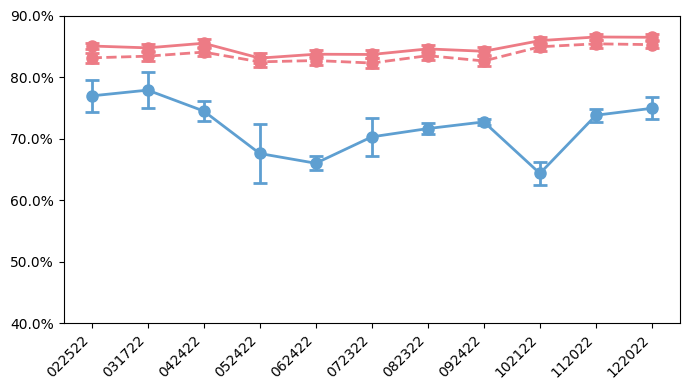

In [49]:
# Read all_runs_results_xxx.csv files from all dates
eval_results_dir = Path("/media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/autosort_input/eval_results")

# Find all date directories
date_dirs = sorted([d for d in eval_results_dir.iterdir() if d.is_dir()])

# Collect data from all dates
all_dates_data = []

for date_dir in date_dirs:
    date = date_dir.name
    csv_path = date_dir / f"all_runs_results_{date}.csv"
    
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        
        # Calculate mean and std for each metric across all runs
        classification_mean = df['classification_accuracy'].mean() * 100  # Convert to percentage
        classification_std = df['classification_accuracy'].std() * 100
        
        noise_detection_mean = df['noise_detection_accuracy'].mean() * 100
        noise_detection_std = df['noise_detection_accuracy'].std() * 100
        
        noise_detection_adjusted_mean = df['noise_detection_accuracy_adjusted'].mean() * 100
        noise_detection_adjusted_std = df['noise_detection_accuracy_adjusted'].std() * 100
        
        all_dates_data.append({
            'date': date,
            'classification_mean': classification_mean,
            'classification_std': classification_std,
            'noise_detection_mean': noise_detection_mean,
            'noise_detection_std': noise_detection_std,
            'noise_detection_adjusted_mean': noise_detection_adjusted_mean,
            'noise_detection_adjusted_std': noise_detection_adjusted_std,
        })
    else:
        print(f"Warning: {csv_path} does not exist, skipping date {date}")

# Convert to DataFrame for easier plotting
if len(all_dates_data) > 0:
    plot_df = pd.DataFrame(all_dates_data)
    plot_df = plot_df.sort_values('date')  # Sort by date
    
    # Create figure
    fig, ax = plt.subplots(figsize=(7, 4))
    
    # X-axis: date indices
    x_pos = np.arange(len(plot_df))
    
    # Plot three lines with error bars
    ax.errorbar(
        x_pos, 
        plot_df['classification_mean'], 
        yerr=plot_df['classification_std'],
        marker='o', 
        linestyle='-', 
        linewidth=2, 
        markersize=8,
        capsize=5,
        capthick=2,
        label='Classification Accuracy',
        color='#5E9FD1'
    )
    
    ax.errorbar(
        x_pos, 
        plot_df['noise_detection_mean'], 
        yerr=plot_df['noise_detection_std'],
        marker='o', 
        linestyle='--', 
        linewidth=2, 
        markersize=8,
        capsize=5,
        capthick=2,
        label='Noise Detection Accuracy',
        color='#ED7B85'
    )
    
    ax.errorbar(
        x_pos, 
        plot_df['noise_detection_adjusted_mean'], 
        yerr=plot_df['noise_detection_adjusted_std'],
        marker='o', 
        linestyle='-', 
        linewidth=2, 
        markersize=8,
        capsize=5,
        capthick=2,
        label='Noise Detection Accuracy (Adjusted)',
        color='#ED7B85'
    )
    
    # Set x-axis labels
    ax.set_xticks(x_pos)
    ax.set_xticklabels(plot_df['date'], rotation=45, ha='right')
        
    # Add grid
    ax.grid(False)
        
    # Set y-axis limits (0-100%)
    ax.set_ylim(40, 90)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}%'))
    
    plt.tight_layout()
    
    # Save figure
    output_fig_path = Path(save_dir) / "accuracy_trends_all_dates.pdf"
    plt.savefig(output_fig_path, dpi=300, bbox_inches='tight')
    print(f"\nAccuracy trends plot saved to: {output_fig_path}")
    
    # Also save as PNG
    output_fig_path_png = Path(save_dir) / "accuracy_trends_all_dates.png"
    plt.savefig(output_fig_path_png, dpi=300, bbox_inches='tight')
    print(f"Accuracy trends plot (PNG) saved to: {output_fig_path_png}")
    
    plt.show()

else:
    print("Warning: No data found to plot")


## Step 7: Real-time Processing Time Benchmark


In [42]:
import time
from utils_clean import detect_spike

def process_single_window_timing(
    recording_f,
    autosort_model,
    calibration_results,
    start_frame,
    time_window_seconds,
    detection_params,
    window_params,
    device=None,
):
    """
    Process a single time window and measure processing time.
    Returns processing time in seconds (from threshold detection to output results).
    
    Parameters:
        time_window_seconds: size of the processing window in seconds (not waveform window)
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    left_sample = window_params['left_sample']
    right_sample = window_params['right_sample']
    window_size = left_sample + right_sample
    sampling_frequency = recording_f.get_sampling_frequency()
    
    # Get models and mapping from calibration stage
    kmeans_model = calibration_results['kmeans_model']
    pca_model = calibration_results['pca_model']
    cluster_to_neuron_mapping = calibration_results['cluster_to_neuron_mapping']
    
    # Start timing: from threshold detection
    start_time = time.time()
    
    # 1. Load current window data
    window_frames = int(time_window_seconds * sampling_frequency)
    end_frame = min(start_frame + window_frames, recording_f.get_num_samples())
    traces = recording_f.get_traces(start_frame=start_frame, end_frame=end_frame)
    if traces.shape[0] > traces.shape[1] and traces.shape[0] > 100:
        traces = traces.T
    traces = traces.astype(np.float32)
    
    # 2. Threshold detection
    trace0_car = traces.T  # (n_timepoints, n_channels)
    spikes = detect_spike(trace0_car, **detection_params)
    spike_coords = np.argwhere(spikes == 1)  # (n_spikes, 2) [time, channel]
    
    if len(spike_coords) == 0:
        # No spikes detected, return 0 time
        return 0.0
    
    # 3. Extract waveforms and filter boundaries
    waveforms = []
    spike_times = []
    spike_channels = []
    
    for time_idx, channel_idx in spike_coords:
        global_time_idx = start_frame + time_idx
        local_start = time_idx - left_sample
        local_end = time_idx + right_sample
        
        if local_start < 0 or local_end > trace0_car.shape[0]:
            continue
        if local_end - local_start != window_size:
            continue
        
        # Extract waveform (n_channels, window_size)
        waveform = traces[:, local_start:local_end]  # (n_channels, window_size)
        waveforms.append(waveform)
        spike_times.append(global_time_idx)
        spike_channels.append(channel_idx)
    
    if len(waveforms) == 0:
        return 0.0
    
    waveforms = np.array(waveforms)  # (n_spikes, n_channels, window_size)
    
    # 4. Pass through noise classifier, classified as spikes
    batch_size = 2048
    n_spikes = len(waveforms)
    way3_features_list = []
    way3_spike_indices = []
    
    autosort_model.eval()
    with torch.no_grad():
        for i in range(0, n_spikes, batch_size):
            batch_end = min(i + batch_size, n_spikes)
            batch_waveforms = waveforms[i:batch_end]
            batch_channels = spike_channels[i:batch_end]
            
            # Extract single waveform and multi waveform
            batch_single_waveforms = []
            batch_multi_waveforms = []
            
            for wf, ch in zip(batch_waveforms, batch_channels):
                multi_wf = wf.flatten()
                batch_multi_waveforms.append(multi_wf)
                single_wf = wf[ch, :]
                batch_single_waveforms.append(single_wf)
            
            batch_multi_waveforms = np.array(batch_multi_waveforms)
            batch_single_waveforms = np.array(batch_single_waveforms)
            
            # Convert to tensor
            batch_multi = torch.from_numpy(batch_multi_waveforms).float().to(device)
            batch_single = torch.from_numpy(batch_single_waveforms).float().to(device)
            
            # Concatenate
            codes = torch.cat((batch_multi, batch_single), dim=1)
            
            # Noise classification
            noise_output = autosort_model.clsfier_noise(codes)
            noise_pred = torch.argmax(noise_output, dim=1)
            
            # Keep only samples classified as spikes
            spike_mask = noise_pred == 1
            if spike_mask.sum() > 0:
                batch_spike_indices = np.arange(i, batch_end)[spike_mask.cpu().numpy()]
                way3_spike_indices.extend(batch_spike_indices.tolist())
                
                # Extract way3 layer features (only for spike samples)
                codes_spike = codes[spike_mask]
                way3_batch = autosort_model.clsfier_label.intermediate_forward(codes_spike)
                way3_features_list.append(way3_batch.cpu().numpy())
    
    if len(way3_features_list) == 0:
        # No spikes passed noise classifier
        end_time = time.time()
        return end_time - start_time
    
    # Combine features for all spikes
    way3_features = np.concatenate(way3_features_list, axis=0)  # (n_spikes_passed, 100)
    
    # 5. PCA dimensionality reduction
    way3_pca = pca_model.transform(way3_features)  # (n_spikes_passed, 30)
    
    # 6. K-means prediction
    cluster_labels = kmeans_model.predict(way3_pca)  # (n_spikes_passed,)
    
    # 7. Map to train neuron ID (this is the end of processing)
    neuron_predictions = []
    for cluster_id in cluster_labels:
        if cluster_id in cluster_to_neuron_mapping:
            neuron_predictions.append(cluster_to_neuron_mapping[cluster_id])
        else:
            neuron_predictions.append('unmatch')
    
    # End timing: after mapping to train neuron ID
    end_time = time.time()
    
    return end_time - start_time


# Test parameters
window_sizes_ms = [100, 200, 300, 400, 500, 1000]  # milliseconds
n_runs_per_window = 50  # Number of segments to process for each window size
sampling_frequency = recording_f.get_sampling_frequency()

# Detection parameters (use same as in evaluation)
detection_params = {
    'thr_min': 3.5,
    'thr_max': 30,
    'distance': 3,
    'ch_max_simul_firing': 5,
    'wlen': 5,
    'prominence': 10,
}

# Window parameters for waveform extraction (fixed, not related to processing window size)
window_params = {
    'left_sample': 10,
    'right_sample': 20,
}

# Initialize results DataFrame
timing_results = []

print("=" * 80)
print("Real-time Processing Time Benchmark")
print("=" * 80)
print(f"Processing window sizes to test: {window_sizes_ms} ms")
print(f"Number of runs per window size: {n_runs_per_window}")
print(f"Sampling frequency: {sampling_frequency} Hz")
print(f"Waveform window params: {window_params}")
print("=" * 80)

# Check if calibration_results exists
if 'calibration_results' not in locals() or calibration_results is None:
    raise ValueError("calibration_results not found. Please run calibration stage (Cell 10) first.")

# Process each window size
for window_size_ms in window_sizes_ms:
    print(f"\nTesting processing window size: {window_size_ms} ms")
    
    # Convert to seconds
    time_window_seconds = window_size_ms / 1000.0
    
    # Process n_runs_per_window segments
    segment_times = []
    
    # Start from different time points to get diverse data
    total_duration_samples = recording_f.get_num_samples()
    recording_total_seconds = total_duration_samples / sampling_frequency
    
    # Use time segments from 60s to 3600s (if available), spaced evenly
    start_times_seconds = np.linspace(60, min(3600, recording_total_seconds - time_window_seconds), n_runs_per_window)
    
    for run_idx, start_time_seconds in enumerate(start_times_seconds):
        start_frame = int(start_time_seconds * sampling_frequency)
        
        # Process single window and measure time
        processing_time = process_single_window_timing(
            recording_f=recording_f,
            autosort_model=autosort_model,
            calibration_results=calibration_results,
            start_frame=start_frame,
            time_window_seconds=time_window_seconds,
            detection_params=detection_params,
            window_params=window_params,
            device=device,
        )
        
        segment_times.append(processing_time)
        
        if (run_idx + 1) % 5 == 0:
            print(f"  Completed {run_idx + 1}/{n_runs_per_window} runs")
    
    # Store results
    for run_idx, proc_time in enumerate(segment_times):
        timing_results.append({
            'window_size_ms': window_size_ms,
            'run': run_idx + 1,
            'processing_time_seconds': proc_time,
        })
    
    print(f"  Average processing time: {np.mean(segment_times):.4f} ± {np.std(segment_times):.4f} seconds")
    print(f"  Min: {np.min(segment_times):.4f} seconds, Max: {np.max(segment_times):.4f} seconds")

# Convert to DataFrame
timing_df = pd.DataFrame(timing_results)

# Reshape to (6, 20) format: rows = window sizes, columns = runs
timing_matrix = timing_df.pivot(index='window_size_ms', columns='run', values='processing_time_seconds')
print(f"\n{'='*80}")
print(f"Timing results matrix shape: {timing_matrix.shape}")
print(f"{'='*80}")
print(timing_matrix)

# Save results
timing_df_path = Path(save_dir) / "real_time_processing_timing.csv"
timing_df.to_csv(timing_df_path, index=False)
print(f"\nTiming results saved to: {timing_df_path}")

# Also save the matrix
timing_matrix_path = Path(save_dir) / "real_time_processing_timing_matrix.csv"
timing_matrix.to_csv(timing_matrix_path)
print(f"Timing matrix saved to: {timing_matrix_path}")


Real-time Processing Time Benchmark
Processing window sizes to test: [100, 200, 300, 400, 500, 1000] ms
Number of runs per window size: 50
Sampling frequency: 10000.0 Hz
Waveform window params: {'left_sample': 10, 'right_sample': 20}

Testing processing window size: 100 ms
  Completed 5/50 runs
  Completed 10/50 runs
  Completed 15/50 runs
  Completed 20/50 runs
  Completed 25/50 runs
  Completed 30/50 runs
  Completed 35/50 runs
  Completed 40/50 runs
  Completed 45/50 runs
  Completed 50/50 runs
  Average processing time: 0.0042 ± 0.0027 seconds
  Min: 0.0026 seconds, Max: 0.0227 seconds

Testing processing window size: 200 ms
  Completed 5/50 runs
  Completed 10/50 runs
  Completed 15/50 runs
  Completed 20/50 runs
  Completed 25/50 runs
  Completed 30/50 runs
  Completed 35/50 runs
  Completed 40/50 runs
  Completed 45/50 runs
  Completed 50/50 runs
  Average processing time: 0.0058 ± 0.0005 seconds
  Min: 0.0047 seconds, Max: 0.0070 seconds

Testing processing window size: 300 ms



Bee swarm plot saved to: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/autosort_input/real_time_processing_timing_beeswarm.pdf
Bee swarm plot (PNG) saved to: /media/ubuntu/sda/Spike_Sorting/paper_architecture/01_real_data/01_flexible_probe_30_channels/autosort_input/real_time_processing_timing_beeswarm.png


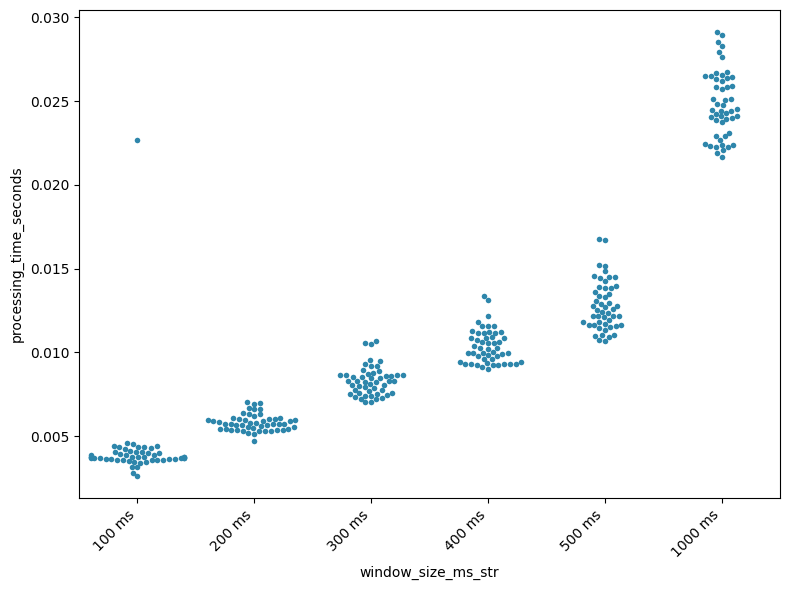

In [48]:
# Plot bee swarm plot
fig, ax = plt.subplots(figsize=(8, 6))

# Prepare data for plotting
plot_data = []
for window_size_ms in window_sizes_ms:
    window_data = timing_df[timing_df['window_size_ms'] == window_size_ms]['processing_time_seconds'].values
    plot_data.append(window_data)

# Create bee swarm plot using seaborn
# First, create a long-format DataFrame for seaborn
plot_df_long = timing_df.copy()
plot_df_long['window_size_ms_str'] = plot_df_long['window_size_ms'].astype(str) + ' ms'

# Create bee swarm plot
sns.swarmplot(
    data=plot_df_long,
    x='window_size_ms_str',
    y='processing_time_seconds',
    ax=ax,
    size=4,
    alpha=1,
    color='#2E86AB'
)
ax.grid(False)

# Rotate x-axis labels if needed
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save figure
output_fig_path = Path(save_dir) / "real_time_processing_timing_beeswarm.pdf"
plt.savefig(output_fig_path, dpi=300, bbox_inches='tight')
print(f"\nBee swarm plot saved to: {output_fig_path}")

# Also save as PNG
output_fig_path_png = Path(save_dir) / "real_time_processing_timing_beeswarm.png"
plt.savefig(output_fig_path_png, dpi=300, bbox_inches='tight')
print(f"Bee swarm plot (PNG) saved to: {output_fig_path_png}")

plt.show()

